# Common

In [1027]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Any, Callable, List
from scipy.optimize import curve_fit
import sys
import uncertainties.unumpy as unp

np.set_printoptions(linewidth=200)

In [1028]:
# --- Класс для параметров стиля ---
@dataclass
class PlotParams:
    """Контейнер для параметров стиля отрисовки."""
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

# --- Класс-обертка для Matplotlib ---
class Plotter:
    """Класс для инкапсуляции всей логики построения графиков."""
    def __init__(self, title: str, xlabel: str, ylabel: str, figsize: tuple = (16, 9)):
        """Инициализирует фигуру и оси, задает основные подписи."""
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=20, pad=30)
        self.ax.set_xlabel(xlabel, fontsize=18, labelpad=20)
        self.ax.set_ylabel(ylabel, fontsize=18, labelpad=20)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает точки."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def add_fit_line(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает сплошную линию (обычно для аппроксимации)."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
        )

    def add_errorbar_points(self, x: np.ndarray, y: np.ndarray,
                            xerr: Optional[np.ndarray], yerr: Optional[np.ndarray],
                            params: PlotParams):
        """Отрисовывает экспериментальные точки с погрешностями."""
        self.ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=yerr,
            fmt=params.marker,
            color=params.color,
            markersize=params.markersize,
            elinewidth=params.linewidth,
            capsize=params.capsize,
            capthick=params.linewidth,
            markevery=params.markevery,
            label=params.label
        )

    def finalize_and_show(self, save_path: Optional[str] = None):
        """Настраивает финальное оформление, сохраняет и/или показывает график."""
        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path)
            print(f"График сохранен в файл: {save_path}")

        plt.show()
        plt.close(self.fig)

In [1029]:
def round_with_uncertainty(value: float, uncertainty: float) -> tuple[float, float]:
    """Округляет значение и погрешность по первой значащей цифре погрешности."""
    if uncertainty == 0 or not np.isfinite(uncertainty) or uncertainty < 1e-12:
        return value, uncertainty
    # Определяем порядок для округления на основе погрешности
    order = -int(np.floor(np.log10(abs(uncertainty))))
    return round(value, order), round(uncertainty, order)

def scale_to_scientific(val: float, sigm: float) -> tuple:
    """
    Рассчитывает компоненты для вывода в научном формате (мантисса, порядок и т.д.).
    Возвращает: (округленные val и sigm, мантиссы, порядок, отн. погрешность).
    """
    val_rounded, sigm_rounded = round_with_uncertainty(val, sigm)
    
    # Расчет относительной погрешности
    if np.isclose(val_rounded, 0):
        varepsilon = float('inf')
    else:
        varepsilon = np.abs(sigm_rounded / val_rounded * 100)

    # Определяем порядок числа для научной нотации
    if np.isclose(val_rounded, 0):
        scale_order = 0
    else:
        # Порядок определяется по абсолютному значению округленной величины
        scale_order = -int(np.floor(np.log10(abs(val_rounded))))

    if scale_order != 0:
        latex_value = val_rounded * 10**scale_order
        latex_uncertainty = sigm_rounded * 10**scale_order
    else:
        latex_value = val_rounded
        latex_uncertainty = sigm_rounded

    return val_rounded, sigm_rounded, latex_value, latex_uncertainty, scale_order, varepsilon

def print_parameter_report(val: float, sigm: float, parameter_name: str, unit: str = ""):
    """
    Печатает полный отчет по одному параметру.
    Включает сырые данные, округленные и LaTeX-формат с научной нотацией.
    """
    # Получаем все необходимые компоненты
    val_r, sigm_r, lat_val, lat_sigm, order, eps = scale_to_scientific(val, sigm)
    
    # Печатаем отчет
    print(f"------------ {parameter_name} ------------")
    print(f"Raw value     : {val} ± {sigm}")
    print(f"Rounded value : {val_r} ± {sigm_r}")
    
    # Формируем LaTeX строку с учетом порядка
    if order != 0:
        # f-строка с тройными скобками: {{}} для вывода фигурных скобок в LaTeX
        # и {} для подстановки переменной
        if order > 0:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{-{order}}}$ \\ {unit} $(\\varepsilon = {eps:.2f}\\%)$")
        else:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{{-order}}}$ \\ {unit}  $(\\varepsilon = {eps:.2f}\\%)$")
    else:
        print(f"LaTeX: $\\left( {val_r:.4f} \\pm {sigm_r:.4f} \\right)$ \\ {unit},  $(\\varepsilon = {eps:.2f}\\%)$")
    print()

def print_fit_summary(arguments: List[str], popt: np.ndarray, sigm_arr: np.ndarray):
    """
    Печатает сводку по всем результатам аппроксимации.
    """
    print("="*50)
    print("             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ")
    print("="*50)
    for arg, val, sigm in zip(arguments, popt, sigm_arr):
        print_parameter_report(val, sigm, arg)


In [1030]:
def load_data(filename: str):
    """Загружает данные из текстового файла."""
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

def calculate_errors(xdata: np.ndarray, ydata: np.ndarray, config: Dict[str, Any]) -> tuple[np.ndarray, np.ndarray]:
    """
    Гибко вычисляет массивы погрешностей для x и y на основе конфигурационного словаря.
    """
    err_type = config.get('type')
    xerr, yerr = None, None # По умолчанию погрешностей нет

    if err_type == 'absolute':
        xerr = np.full_like(xdata, config.get('x_val', 0))
        yerr = np.full_like(ydata, config.get('y_val', 0))
    elif err_type == 'percent':
        xerr = config.get('x_val', 0) * xdata
        yerr = config.get('y_val', 0) * ydata
    elif err_type == 'custom':
        xerr = config.get('x_val')
        yerr = config.get('y_val')
        
    # Если какой-то из массивов не был создан, заменяем его на массив нулей
    if xerr is None:
        xerr = np.zeros_like(xdata)
    if yerr is None:
        yerr = np.zeros_like(ydata)
        
    return xerr, yerr

In [1031]:
def load_data(filename: str):
    """Загружает данные из текстового файла с двумя колонками."""
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

# Settings

In [1032]:
# arguments = ['a']
# def func_ax(x, a):
#     return a * x

arguments = ['a', 'b']
def func_axpb(x, a, b):
    return a * x + b

# arguments = ['a', 'b', 'c', 'd']
# def polinomial_func(x, a, b, c, d):
#     return a * x**3 + b * x**2 + c * x + d

# arguments = ['y0', 'power', 'bias']
# def exponential_func(x, y0, power, bias):
#     return y0 * np.exp(power * x) + bias

In [1033]:
func = func_axpb

# Changable parameters

In [1034]:
filename_calibration = 'data_calibration.txt'
data = np.loadtxt(filename_calibration)

# (0 --- np.inf)
error_config = \
{
    'type': 'absolute', 
    'x_val': 0, 
    'y_val': data[:, 2]
}

# # (0 --- 1)
# error_config = \
# {
#     'type': 'percent', 
#     'x_val': 0.05, 
#     'y_val': 0.1
# }

# # User errors
# error_config = \
# {
#     'type': 'custom', 
#     'x_val': np.full_like(I_data, 0.02), 
#     'y_val': error_N_net,
# }

# Run

In [1035]:
filename_calibration = 'data_calibration.txt'
x, y = load_data(filename_calibration)

In [1036]:
# 2. Расчет погрешностей
xerr, yerr = calculate_errors(x, y, error_config)

# 3. Аппроксимация
popt, pcov = curve_fit(func, x, y, sigma=yerr, absolute_sigma=True)

# 4. Вывод результатов
print_fit_summary(arguments, popt, np.sqrt(np.diag(pcov)))

# Извлечем нужные параметры для дальнейших расчетов
a_calibration, b_calibration = popt

a_calibration_u = unp.uarray(a_calibration, np.sqrt(pcov[0, 0]))
b_calibration_u = unp.uarray(b_calibration, np.sqrt(pcov[1, 1]))

             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ a ------------
Raw value     : 1319.6857422152182 ± 52.8730070006188
Rounded value : 1320.0 ± 50.0
LaTeX: $\left( 1.320 \pm 0.050 \right) \cdot 10^{3}$ \   $(\varepsilon = 3.79\%)$

------------ b ------------
Raw value     : 92.19367320736944 ± 46.36804697551287
Rounded value : 90.0 ± 50.0
LaTeX: $\left( 9.000 \pm 5.000 \right) \cdot 10^{1}$ \   $(\varepsilon = 55.56\%)$



In [1037]:
markevery_i = 1
# --- Стили для графика ---
plot_args_dict = \
{
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1, label='Аппроксимация'),
    "Error_bars": PlotParams(color="black", linewidth=2, marker="*", markersize=14, markevery=markevery_i, capsize=3, label="Экспериментальные данные"),
    "Dots":       PlotParams(color="black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
}

График сохранен в файл: ./example-project/pictures/calibrating.pdf


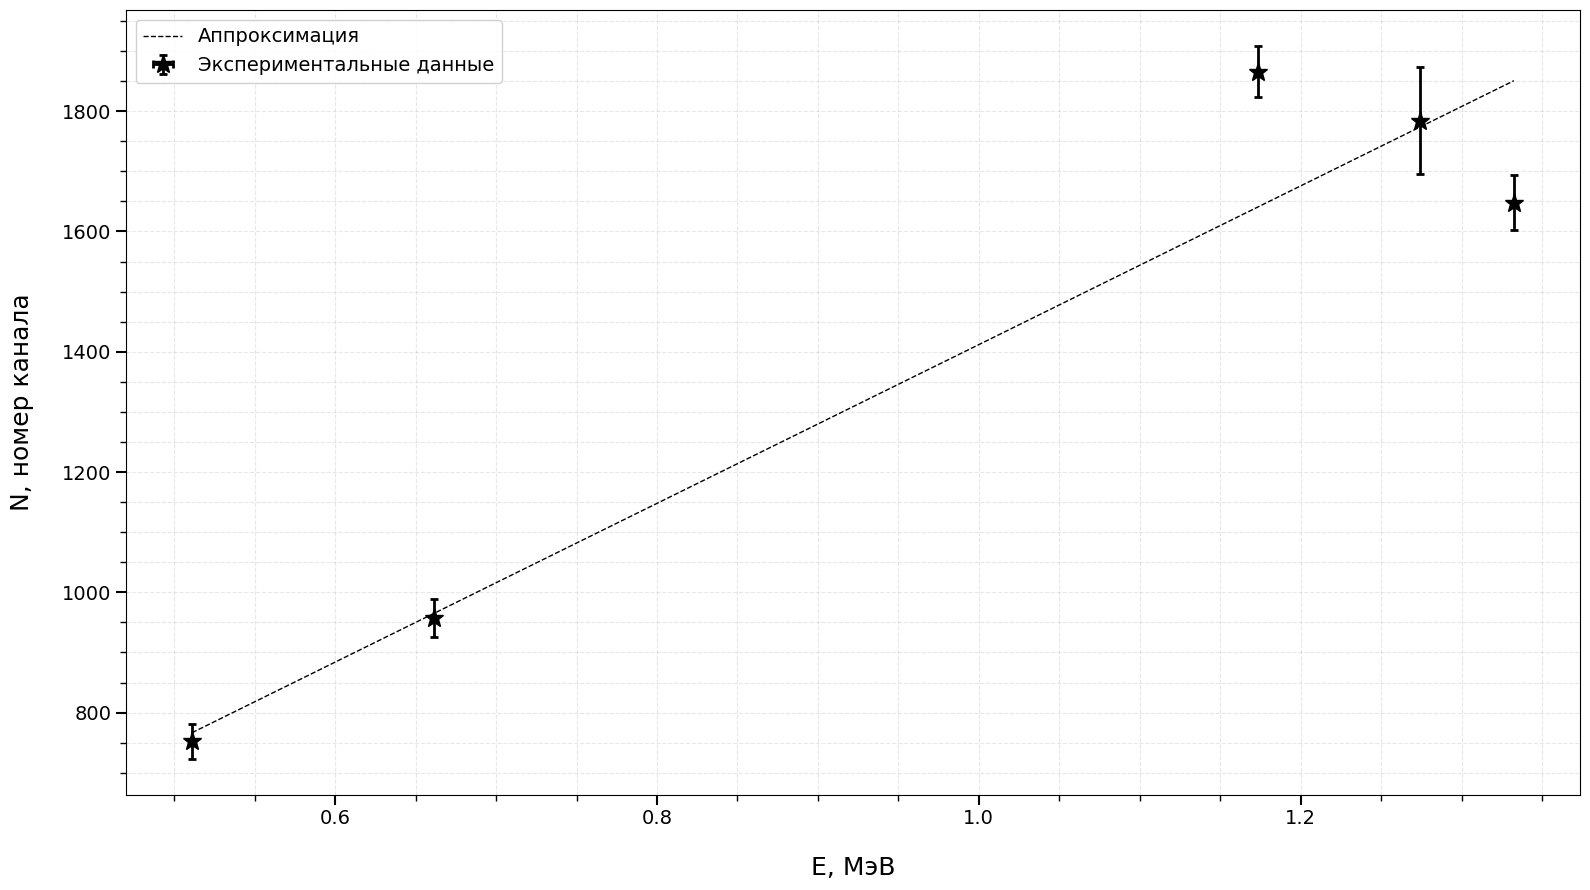

In [1038]:
# --- 2. Построение графика ---
plotter = Plotter(
    title=None,
    xlabel=r'E, МэВ',
    ylabel=r'N, номер канала'
)

# Добавляем экспериментальные точки
plotter.add_errorbar_points(x, y, xerr=xerr, yerr=yerr, params=plot_args_dict['Error_bars'])

# Добавляем кривую аппроксимации
x_smooth = np.linspace(x.min(), x.max(), 500)
y_fit = func(x_smooth, *popt)

plotter.add_fit_line(x_smooth, y_fit, params=plot_args_dict['Fitted'])

# Финализируем и показываем график
plotter.finalize_and_show("./example-project/pictures/calibrating.pdf")


In [1039]:
def calibration_function(N):
    return (N - b_calibration) / a_calibration

def calibration_function_u(N_u):
    E_u = (N_u - b_calibration_u) / a_calibration_u
    return E_u

In [1040]:
np.set_printoptions(precision=15)

# Определяем значения энергии ФОТОПИКОВ и их погрешности для калиброванных каналов

In [1041]:
filename_N_to_E = 'data_N_to_E.txt'
N_arr, N_err_arr = load_data(filename_N_to_E)

N_arr_u = unp.uarray(N_arr, N_err_arr)

E_arr_u = calibration_function_u(N_arr_u)

print("E_arr =", unp.nominal_values(E_arr_u))
print("E_err_arr =", unp.std_devs(E_arr_u))

E_arr = [1.178693913677294 1.344088062064467 0.655211545091632 0.500118697589972 1.282289234385984 0.006478452849145 0.042797050990204 0.01904686214048  0.107391689311377 0.329839341706052]
E_err_arr = [0.068200387846084 0.072071325152188 0.049960744582359 0.046124007467401 0.070648367795367 0.03530927594278  0.035417226098451 0.035682018727431 0.035957779925085 0.04049648555587 ]


In [1042]:
calibration_function(16.29340955748040)

np.float64(-0.05751389230172573)

In [1043]:
load_data(filename_N_to_E)

(array([1647.69922552315, 1865.96752499553,  956.8670073996 ,  752.1931878321 , 1784.41249322262,  100.743195064  ,  148.672331208  ,  117.3295456081 ,  233.916954424  ,  527.4779496785 ]),
 array([45.46031323 , 42.96310667 , 31.57465238 , 29.25478663 , 44.11214805 ,  4.602292228,  5.42907922 ,  8.146704779,  8.339512501, 20.04943491 ]))

# Определяем значения энергии КОМПТОНОВСКИХ КРАЕВ и их погрешности для калиброванных каналов

In [1044]:
filename_N_edge_compton = 'data_N_edge_compton.txt'
N_arr, N_err_arr = load_data(filename_N_edge_compton)

N_arr_u = unp.uarray(N_arr, N_err_arr)

E_arr_u = calibration_function_u(N_arr_u)

print("E_arr =", unp.nominal_values(E_arr_u))
print("E_err_arr =", unp.std_devs(E_arr_u))

E_arr = [0.919011464620978 0.437836303226803 0.292347120569036 1.109208260699621]
E_err_arr = [0.066263907978147 0.045376280080368 0.047858303867703 0.072639878713519]


# Определяем значения энергии ПИКОВ ОБРАТНОГО РАССЕЯНИЯ и их погрешности для калиброванных каналов

In [1045]:
filename_backward_scattering = 'data_backward_scattering.txt'
N_arr, N_err_arr = load_data(filename_backward_scattering)

N_arr_u = unp.uarray(N_arr, N_err_arr)

E_arr_u = calibration_function_u(N_arr_u)

print("E_arr =", unp.nominal_values(E_arr_u))
print("E_err_arr =", unp.std_devs(E_arr_u))

E_arr = [0.21657150460145  0.185292637004752 0.16848722478383 ]
E_err_arr = [0.042738497341165 0.04572721526955  0.04197414294241 ]


In [1046]:
# Как в теории?

# Теоретически находим край коптона

In [1047]:
m_e = 9.10938356e-31 # кг
c = 299792458 # м/с
e = 1.602176634e-19 # Кл

E_e = m_e * c**2 / e / 1e6 # МэВ

E_peaks_arr = [1.178693914, 0.655211545, 0.500118698, 1.282289234]
E_peaks_err_arr = [0.068200388, 0.049960745, 0.046124007, 0.070648368]

E_peaks_arr_u = unp.uarray(E_peaks_arr, E_peaks_err_arr)

E_compton_arr_u =  E_peaks_arr_u / (1 +  E_e / (2 * E_peaks_arr_u))

print("E_compton_arr =", unp.nominal_values(E_compton_arr_u))
print("E_compton_err_arr =", unp.std_devs(E_compton_arr_u))

E_compton_arr = [0.968711303094079 0.471392309025804 0.331012040658749 1.069240315171244]
E_compton_err_arr = [0.066035918721756 0.046028435099169 0.040850466862107 0.068698124625303]


# Рисуем график для комнтоновских краев

In [1048]:
arguments = ['a']
def func_ax(x, a):
    return a * x

In [1049]:
func = func_ax

In [1050]:
filename_compton_edje_comparasion = 'compton_edje_comparasion.txt'
data = np.loadtxt(filename_compton_edje_comparasion)

# (0 --- np.inf)
error_config = \
{
    'type': 'absolute', 
    'x_val': data[:, 1], 
    'y_val': data[:, 3]
}

# Run

In [1051]:
x, y = data[:, 0], data[:, 2]

In [1052]:
# 2. Расчет погрешностей
xerr, yerr = calculate_errors(x, y, error_config)

# 3. Аппроксимация
popt, pcov = curve_fit(func, x, y, sigma=yerr, absolute_sigma=True)

# 4. Вывод результатов
print_fit_summary(arguments, popt, np.sqrt(np.diag(pcov)))

# Извлечем нужные параметры для дальнейших расчетов
a2_calibration = popt

a2_calibration_u = unp.uarray(a2_calibration, np.sqrt(pcov[0, 0]))

             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ a ------------
Raw value     : 1.0248102361643014 ± 0.04095900665992885
Rounded value : 1.02 ± 0.04
LaTeX: $\left( 1.0200 \pm 0.0400 \right)$ \ ,  $(\varepsilon = 3.92\%)$



In [1053]:
markevery_i = 1
# --- Стили для графика ---
plot_args_dict = \
{
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1, label='Аппроксимация'),
    "Error_bars": PlotParams(color="black", linewidth=2, marker="*", markersize=14, markevery=markevery_i, capsize=3, label="Экспериментальные данные"),
    "Dots":       PlotParams(color="black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
}

График сохранен в файл: ./example-project/pictures/compton_comparation.pdf


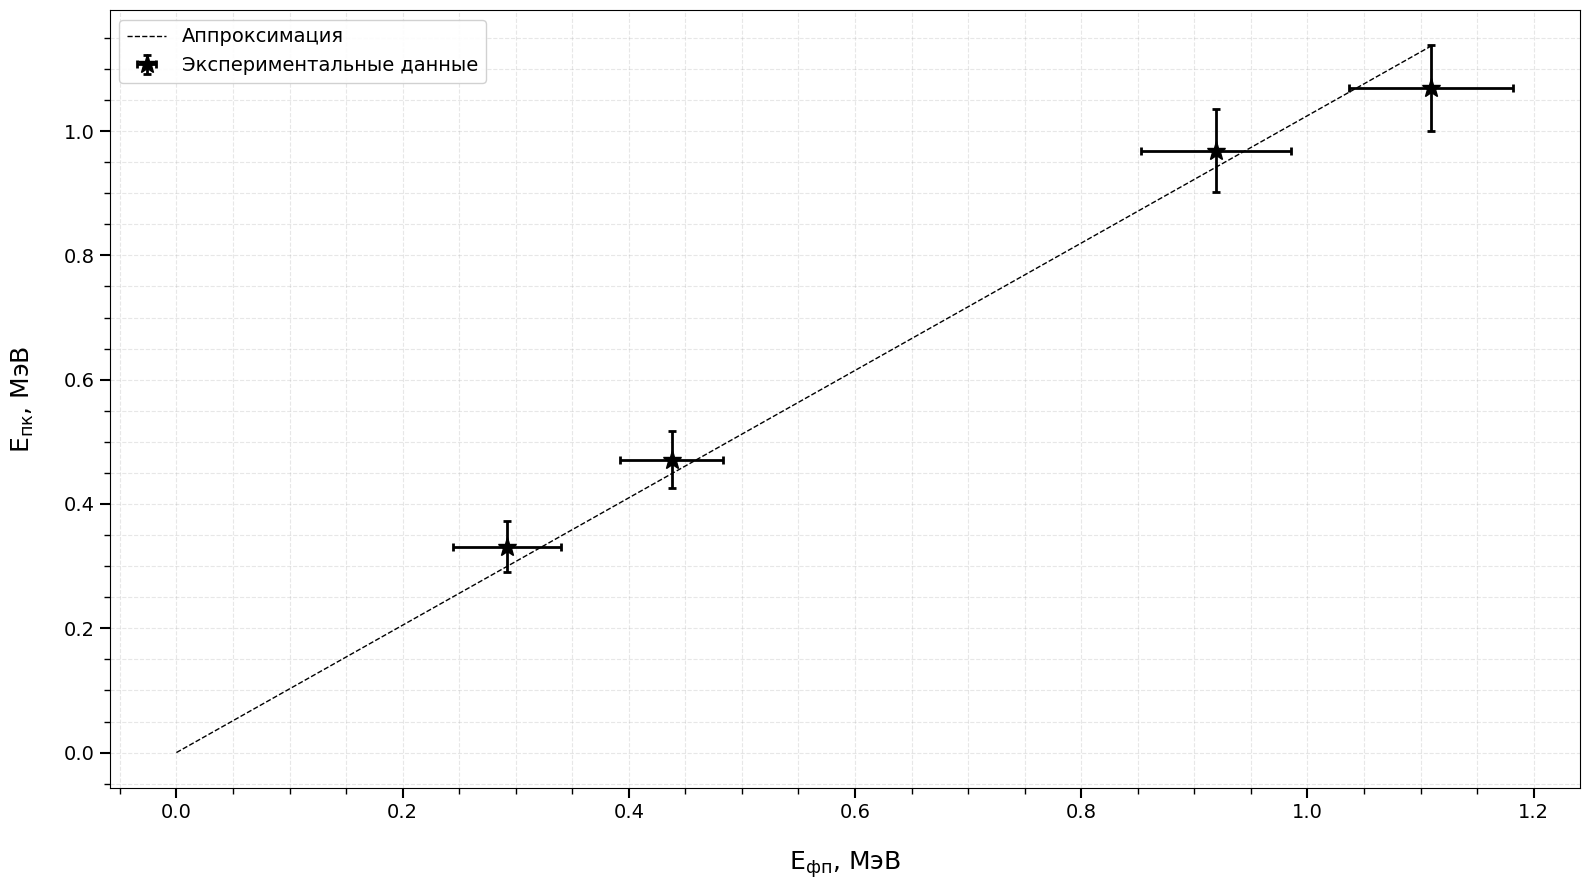

In [1054]:
# --- 2. Построение графика ---
plotter = Plotter(
    title=None,
    xlabel=r'$\mathrm{E_\text{фп}}$, МэВ',
    ylabel=r'$\mathrm{E_\text{пк}}$, МэВ'
)

# Добавляем экспериментальные точки
plotter.add_errorbar_points(x, y, xerr=xerr, yerr=yerr, params=plot_args_dict['Error_bars'])

# Добавляем кривую аппроксимации
x_smooth = np.linspace(0, x.max(), 500)
y_fit = func(x_smooth, *popt)

plotter.add_fit_line(x_smooth, y_fit, params=plot_args_dict['Fitted'])

# Финализируем и показываем график
plotter.finalize_and_show("./example-project/pictures/compton_comparation.pdf")


# График R^2 = f(1/E)

In [1055]:
arguments = ['a']
def func_ax(x, a):
    return a * x

In [1056]:
func = func_ax

In [1057]:
filename_spectrometer_resolution = 'data_R^2=f(1_dev_E).txt'
data = np.loadtxt(filename_spectrometer_resolution)

E_arr, R_arr = data[:, 1], data[:, 0]

E_arr_u = unp.uarray(E_arr, data[:, 2])

x = 1 / E_arr_u
y = R_arr ** 2
# (0 --- np.inf)
error_config = \
{
    'type': 'custom', 
    'x_val': unp.std_devs(x), 
    'y_val': y * 0.05,
}

In [1058]:
print(E_arr)
print(data[:, 2])
print(unp.nominal_values(x))
print(unp.std_devs(x))

[1.178693914 1.344088062 0.655211545 1.282289234]
[0.068200388 0.072071325 0.049960745 0.070648368]
[0.848396677137675 0.743998870514483 1.526224633297632 0.779855256899084]
[0.049089065338722 0.039893951826857 0.116376642473389 0.042966516223703]


# Run

In [1059]:
x = unp.nominal_values(x)
y = unp.nominal_values(y)

In [1060]:
# 2. Расчет погрешностей
xerr, yerr = calculate_errors(x, y, error_config)

# 3. Аппроксимация
popt, pcov = curve_fit(func, x, y)

# 4. Вывод результатов
print_fit_summary(arguments, popt, np.sqrt(np.diag(pcov)))

# Извлечем нужные параметры для дальнейших расчетов
a3_calibration = popt

a3_calibration_u = unp.uarray(a3_calibration, np.sqrt(pcov[0, 0]))

             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ a ------------
Raw value     : 0.003019505026316765 ± 0.00015949047052364048
Rounded value : 0.003 ± 0.0002
LaTeX: $\left( 3.000 \pm 0.200 \right) \cdot 10^{-3}$ \  $(\varepsilon = 6.67\%)$



In [1061]:
markevery_i = 1
# --- Стили для графика ---
plot_args_dict = \
{
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1, label='Аппроксимация'),
    "Error_bars": PlotParams(color="black", linewidth=2, marker="*", markersize=14, markevery=markevery_i, capsize=3, label="Экспериментальные данные"),
    "Dots":       PlotParams(color="black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
}

График сохранен в файл: ./example-project/pictures/spectrometer_resolution.pdf


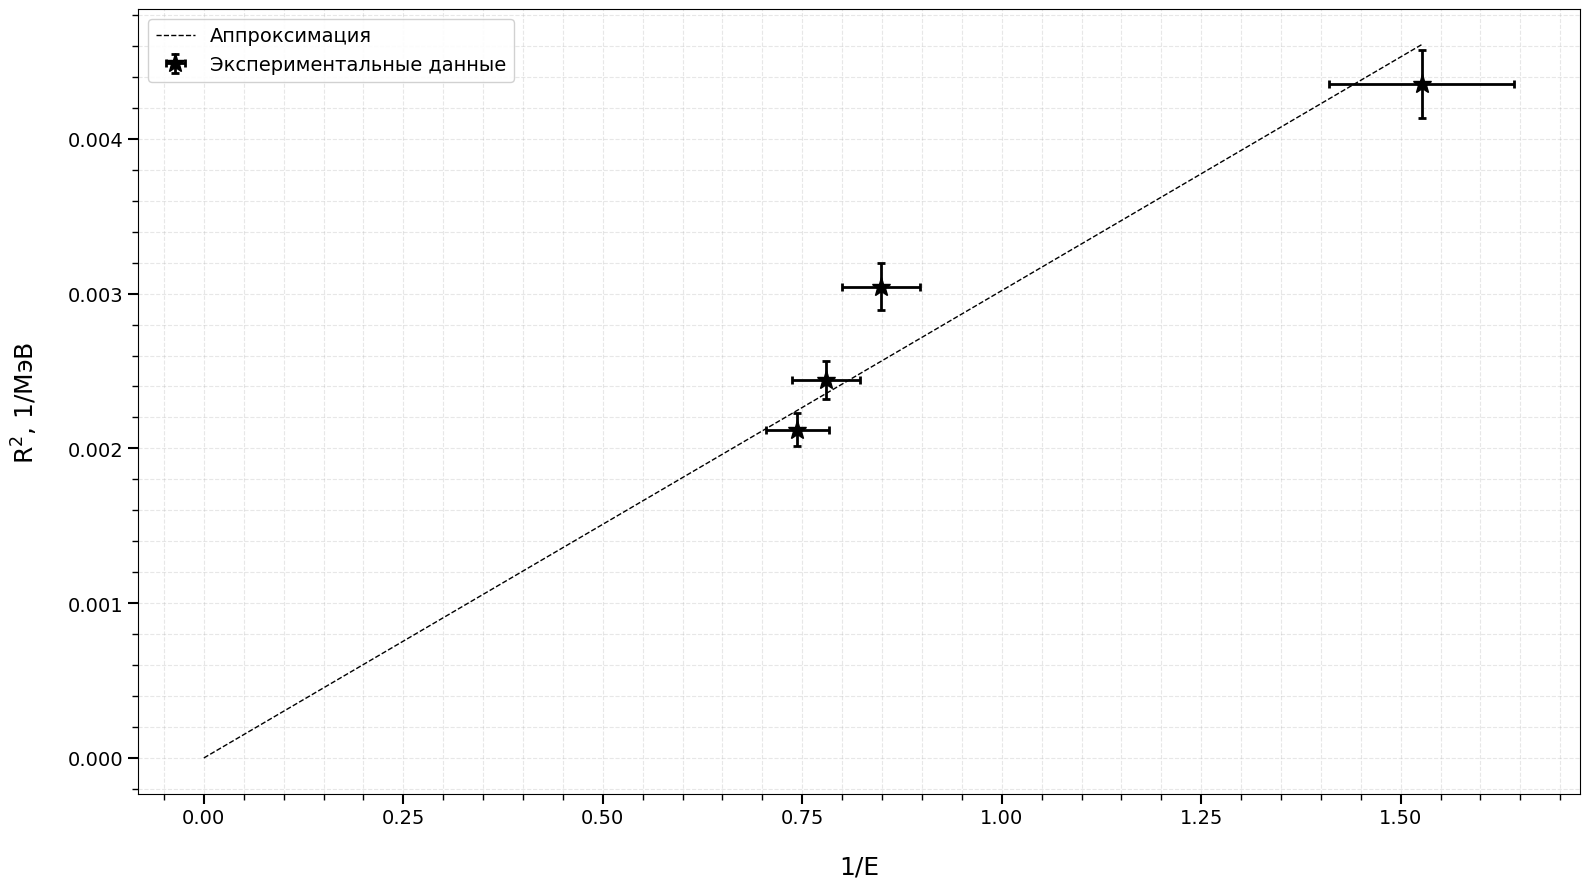

In [1062]:
# --- 2. Построение графика ---
plotter = Plotter(
    title=None,
    xlabel=r'1/E',
    ylabel=r'$\mathrm{R^2}$, 1/МэВ'
)

# Добавляем экспериментальные точки
plotter.add_errorbar_points(x, y, xerr=xerr, yerr=yerr, params=plot_args_dict['Error_bars'])

# Добавляем кривую аппроксимации
x_smooth = np.linspace(0, x.max(), 500)
y_fit = func(x_smooth, *popt)

plotter.add_fit_line(x_smooth, y_fit, params=plot_args_dict['Fitted'])

# Финализируем и показываем график
plotter.finalize_and_show("./example-project/pictures/spectrometer_resolution.pdf")


# Рисуем график для пиков обратного рассеяния краев

In [1063]:
arguments = ['E_e']
def func_ax(x, E_e):
    return x / (1 + (2 * x / E_e))

In [1064]:
func = func_ax

In [1065]:
filename_backward_scattering_graph = 'data_backward_scattering_graph.txt'
data = np.loadtxt(filename_backward_scattering_graph)

# (0 --- np.inf)
error_config = \
{
    'type': 'absolute', 
    'x_val': data[:, 3], 
    'y_val': data[:, 1]
}

# Run

In [1066]:
x, y = data[:, 2], data[:, 0]

In [1067]:
# 2. Расчет погрешностей
xerr, yerr = calculate_errors(x, y, error_config)

# 3. Аппроксимация
popt, pcov = curve_fit(func, x, y, sigma=yerr, absolute_sigma=True)

# 4. Вывод результатов
print_fit_summary(arguments, popt, np.sqrt(np.diag(pcov)))

# Извлечем нужные параметры для дальнейших расчетов
a4_calibration = popt

a4_calibration_u = unp.uarray(a4_calibration, np.sqrt(pcov[0, 0]))

             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ E_e ------------
Raw value     : 0.514687871735835 ± 0.08885537047507287
Rounded value : 0.51 ± 0.09
LaTeX: $\left( 5.100 \pm 0.900 \right) \cdot 10^{-1}$ \  $(\varepsilon = 17.65\%)$



In [1068]:
markevery_i = 1
# --- Стили для графика ---
plot_args_dict = \
{
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1, label='Аппроксимация'),
    "Error_bars": PlotParams(color="black", linewidth=2, marker="*", markersize=14, markevery=markevery_i, capsize=3, label="Экспериментальные данные"),
    "Dots":       PlotParams(color="black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
}

График сохранен в файл: ./example-project/pictures/backward_scattering.pdf


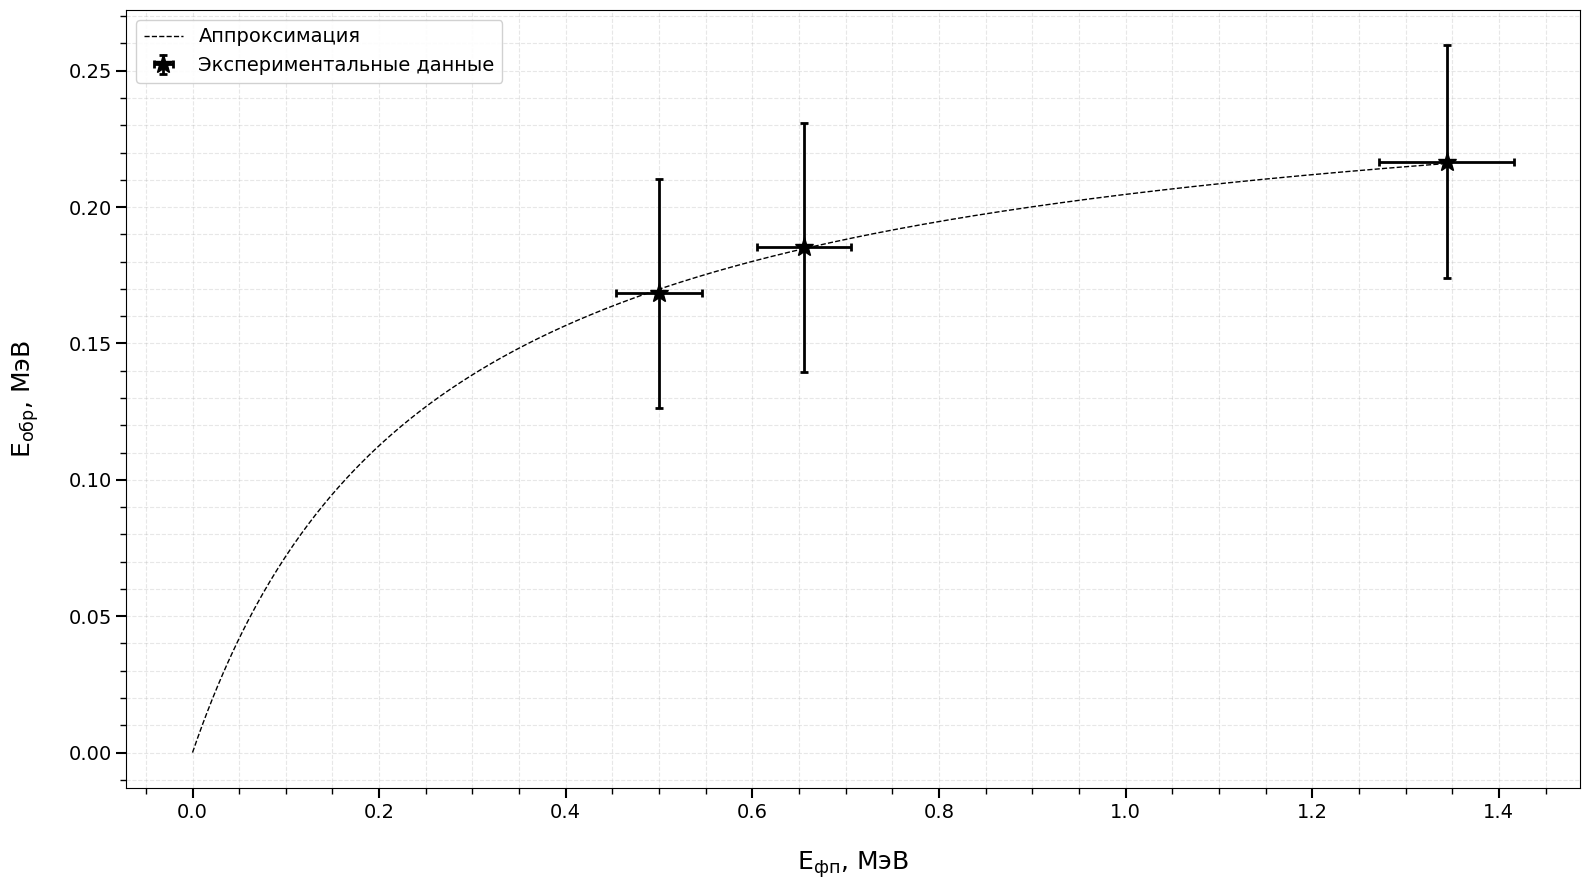

In [1069]:
# --- 2. Построение графика ---
plotter = Plotter(
    title=None,
    xlabel=r'$\mathrm{E_\text{фп}}$, МэВ',
    ylabel=r'$\mathrm{E_\text{обр}}$, МэВ'
)

# Добавляем экспериментальные точки
plotter.add_errorbar_points(x, y, xerr=xerr, yerr=yerr, params=plot_args_dict['Error_bars'])

# Добавляем кривую аппроксимации
x_smooth = np.linspace(0, x.max(), 500)
y_fit = func(x_smooth, *popt)

plotter.add_fit_line(x_smooth, y_fit, params=plot_args_dict['Fitted'])

# Финализируем и показываем график
plotter.finalize_and_show("./example-project/pictures/backward_scattering.pdf")
